In [ ]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [2]:
import fmatoolbox as fma
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
%load_ext autoreload
%autoreload 2

In [43]:
spikes = np.array([
    # Avalanche 1
    [5.00000000e-02, 3.00000000e+00],
    [6.20000000e-02, 7.00000000e+00],
    [7.80000000e-02, 2.00000000e+00],
    [9.10000000e-02, 9.00000000e+00],
    [1.05000000e-01, 4.00000000e+00],
    [1.18000000e-01, 6.00000000e+00],
    [1.32000000e-01, 1.00000000e+01],
    [1.47000000e-01, 5.00000000e+00],
    [1.61000000e-01, 8.00000000e+00],
    [1.76000000e-01, 2.00000000e+00],
    [1.92000000e-01, 7.00000000e+00],
    [2.08000000e-01, 4.00000000e+00],
    [2.23000000e-01, 9.00000000e+00],
    [2.39000000e-01, 6.00000000e+00],

    # (silence)

    # Avalanche 2
    [3.20000000e-01, 1.00000000e+00],
    [3.34000000e-01, 5.00000000e+00],
    [3.48000000e-01, 8.00000000e+00],
    [3.62000000e-01, 3.00000000e+00],
    [3.76000000e-01, 9.00000000e+00],
    [3.90000000e-01, 2.00000000e+00],
    [4.04000000e-01, 6.00000000e+00],
    [4.18000000e-01, 4.00000000e+00],
    [4.32000000e-01, 7.00000000e+00],
    [4.47000000e-01, 1.00000000e+01],
    [4.62000000e-01, 3.00000000e+00],
    [4.78000000e-01, 8.00000000e+00],
    [4.94000000e-01, 5.00000000e+00],
    [5.10000000e-01, 2.00000000e+00],
    [5.26000000e-01, 9.00000000e+00],
])

In [8]:
def avalanchesplot(session=None, spikes=None, FR=None, bin_size=0.05, neurons=None, tmax=50, threshold=30, smoothed=False, window=5, time_step=None):#neurons = nombre de neurones à prendre en compte, tmax = durée max à prendre en compte, threshold = seuil pour définir les avalanches, smoothed = si on veut afficher la courbe lissée, window = taille de la fenêtre pour le lissage 
    
    if spikes is None and session is None:
        return "Please provide either a session or spike times."
    if session is not None:
        spikes_indiv = fma.data.loadSpikeTimes(session)
    if spikes is not None:
        spikes_indiv = {}
        d = {}
        for value, neuron in spikes:
            neuron = np.uint(neuron)
            if neuron not in d:
                d[neuron] = []
            d[neuron].append(value)
        for neuron, values in d.items():
            spikes_indiv[neuron] = values
    if neurons is not None:
        spikes_indiv = dict(list(spikes_indiv.items())[:neurons])
    spikes_indiv = {key: fma.general.restrict(spikes_indiv[key], [0, tmax]) for key in spikes_indiv} 
    


    if spikes is None:
        spikes = fma.data.loadSpikeTimes(session, output='compact')
    if neurons is not None:
        ind = spikes[:,1] < neurons
        spikes = spikes[ind,:]
    spikes = spikes[(spikes[:,0] >= 0) & (spikes[:,0] <= tmax),:]
    if FR is None:
        FR = fma.analysis.firingRate(spikes[:,0], bin_size=bin_size)
    else:
        FR = FR[FR[:,0] <= tmax,:]
    time = FR[:, 0]
    rates = FR[:, 1]
    if smoothed:
        smoothed_rates = np.convolve(rates, np.ones(window)/window, mode='same')
    if time_step is None:
        time_step=FR[1,0] - FR[0,0]

    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=threshold,
        time_step=time_step,
        t0=FR[0,0]
    )

    print(intervals)
    print(f"tmax = {time[-1]}")
    

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10), sharex=True)

    for n, (neuron_id, spike_times) in enumerate(spikes_indiv.items()):
    # transforme la liste en array si nécessaire
        spike_times = np.array(spike_times)
    
    # y = n pour ce neurone
        ax1.scatter(spike_times, 
                [neuron_id] * len(spike_times), 
                marker='|', 
                s=100,     # taille du trait
                color='black')
    
    for t1, t2 in intervals:
        ax1.axvspan(t1, t2, color='red', alpha=0.3)


    ax2.plot(time[:len(rates)] , rates, color='green', label='Firing rate')
    if smoothed:
        ax2.plot(time[:len(smoothed_rates)], smoothed_rates, color='blue', label='Smoothed firing rate')
    for t1, t2 in intervals:
        ax2.axvspan(t1, t2, color='red', alpha=0.3)

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Neuron Index")
    ax1.set_title("Spikes with avalanches")

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Firing rate (Hz)")
    ax2.set_title("Firing rate (moving average) with avalanches")
    ax2.legend()

    
    plt.show()


[[244.1  244.12]
 [244.48 244.5 ]
 [249.16 249.18]
 [249.24 249.26]
 [249.34 249.36]
 [250.16 250.18]
 [250.78 250.8 ]
 [252.28 252.3 ]
 [255.9  255.92]
 [255.98 256.  ]
 [256.12 256.14]
 [256.36 256.38]
 [257.02 257.04]
 [258.46 258.48]
 [258.56 258.58]
 [259.   259.02]]
tmax = 259.99


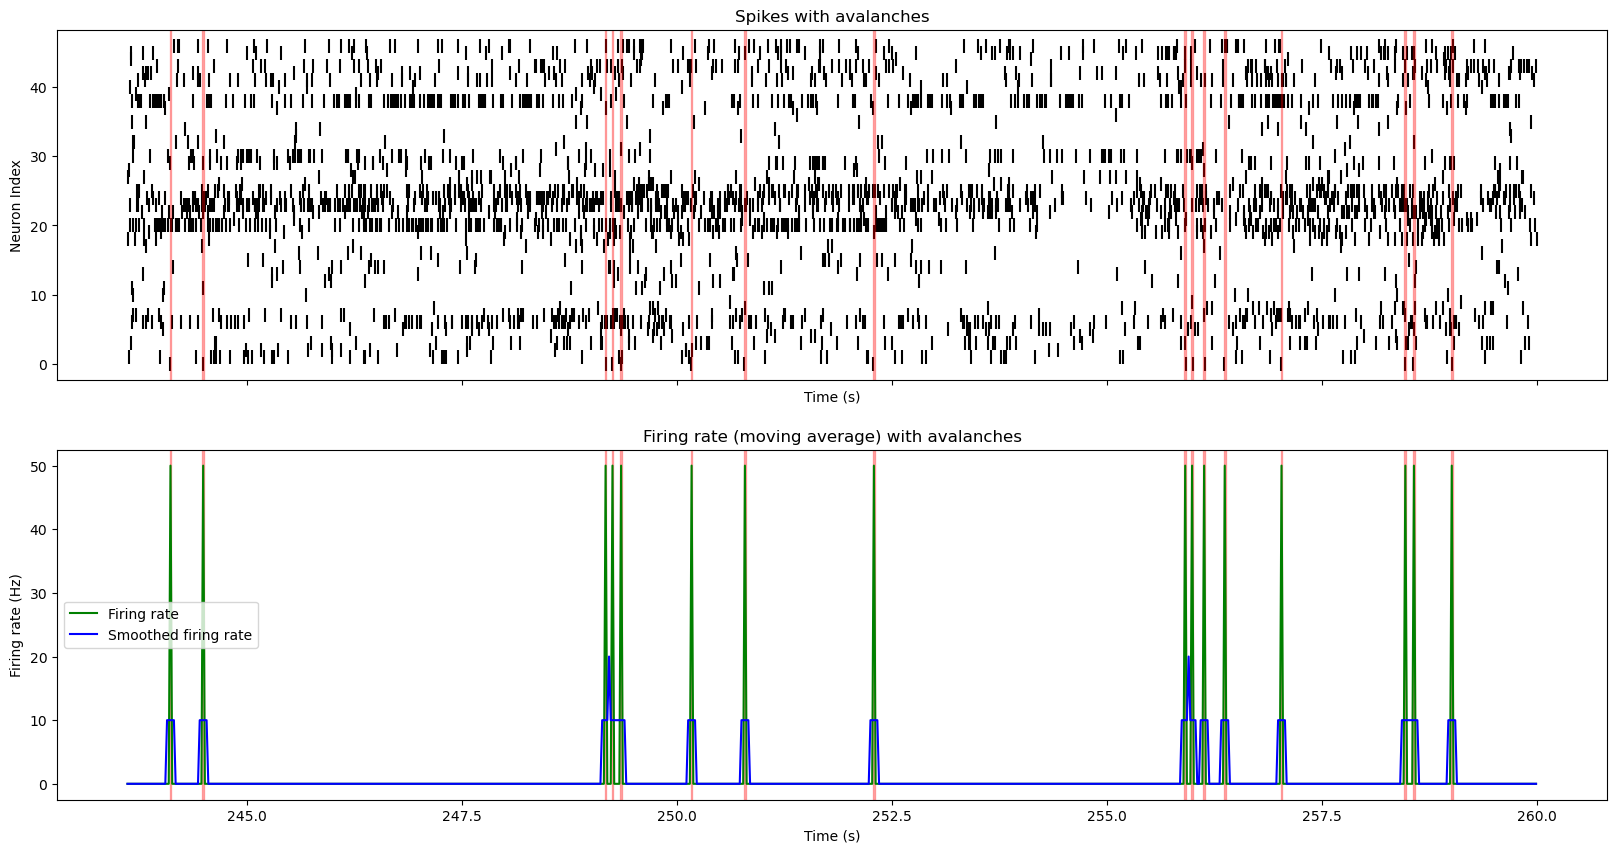

In [55]:
fr = R.unitFiringRate(regs=["nr"], states = "sws", window = 0.02)
sp= R.spikes(regs=["nr"], state='sws')
avalanchesplot(session, spikes = sp, FR=fr, tmax=260, smoothed=True, bin_size = 0.02, threshold=0)

[[5.0000e-03 8.5000e-02]
 [9.5000e-02 3.0500e-01]
 [3.1500e-01 3.7500e-01]
 [3.8500e-01 4.6500e-01]
 [4.7500e-01 5.3500e-01]
 [5.4500e-01 5.7500e-01]
 [5.8500e-01 7.3500e-01]
 [7.6500e-01 7.9500e-01]
 [8.0500e-01 9.3500e-01]
 [9.4500e-01 1.2150e+00]
 [1.2250e+00 1.2850e+00]
 [1.2950e+00 1.4450e+00]
 [1.4550e+00 1.4750e+00]
 [1.4850e+00 1.6550e+00]
 [1.6650e+00 1.7150e+00]
 [1.7250e+00 1.8750e+00]
 [1.8850e+00 1.9450e+00]
 [1.9550e+00 1.9950e+00]
 [2.0050e+00 2.0450e+00]
 [2.0550e+00 2.5250e+00]
 [2.5350e+00 2.8850e+00]
 [2.8950e+00 3.1950e+00]
 [3.2050e+00 3.3350e+00]
 [3.3450e+00 3.3950e+00]
 [3.4050e+00 3.4450e+00]
 [3.4550e+00 3.5050e+00]
 [3.5150e+00 3.7950e+00]
 [3.8050e+00 4.1850e+00]
 [4.1950e+00 4.3250e+00]
 [4.3350e+00 4.3550e+00]
 [4.3650e+00 4.4150e+00]
 [4.4250e+00 4.4750e+00]
 [4.4850e+00 4.6850e+00]
 [4.7050e+00 4.8450e+00]
 [4.8550e+00 5.0450e+00]
 [5.0550e+00 5.0950e+00]
 [5.1050e+00 5.1250e+00]
 [5.1350e+00 5.3050e+00]
 [5.3150e+00 5.3250e+00]
 [5.3350e+00 5.3450e+00]


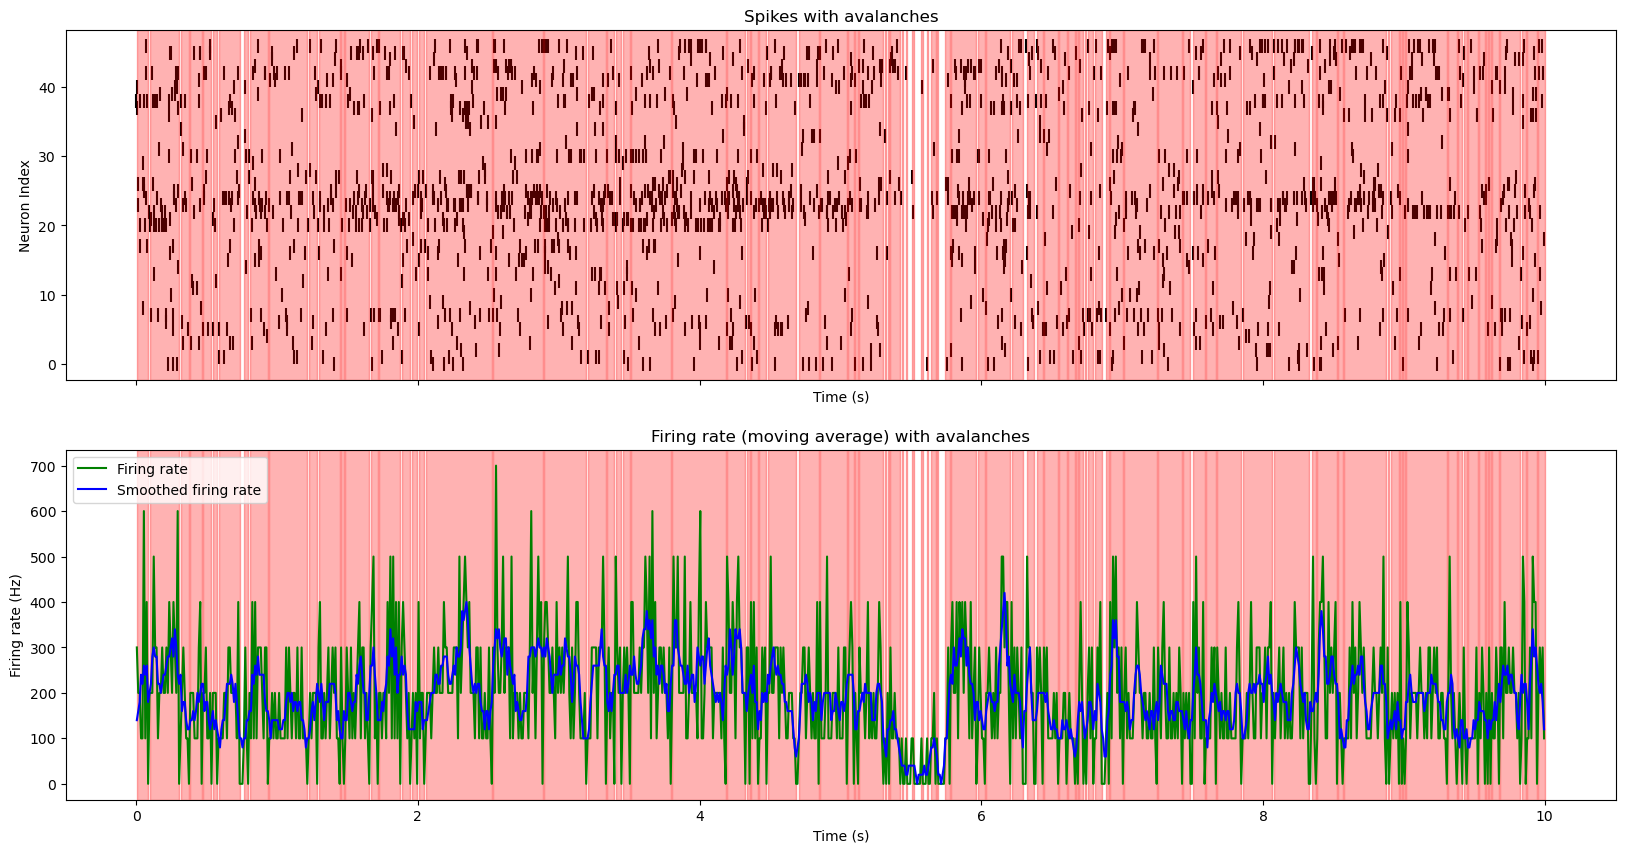

In [12]:
avalanchesplot(spikes=spikes, FR=fr,tmax=10, smoothed=True, bin_size = 0.05, threshold=0, window=5)

[[0.05 0.25]
 [0.3  0.5 ]]
tmax = 0.475


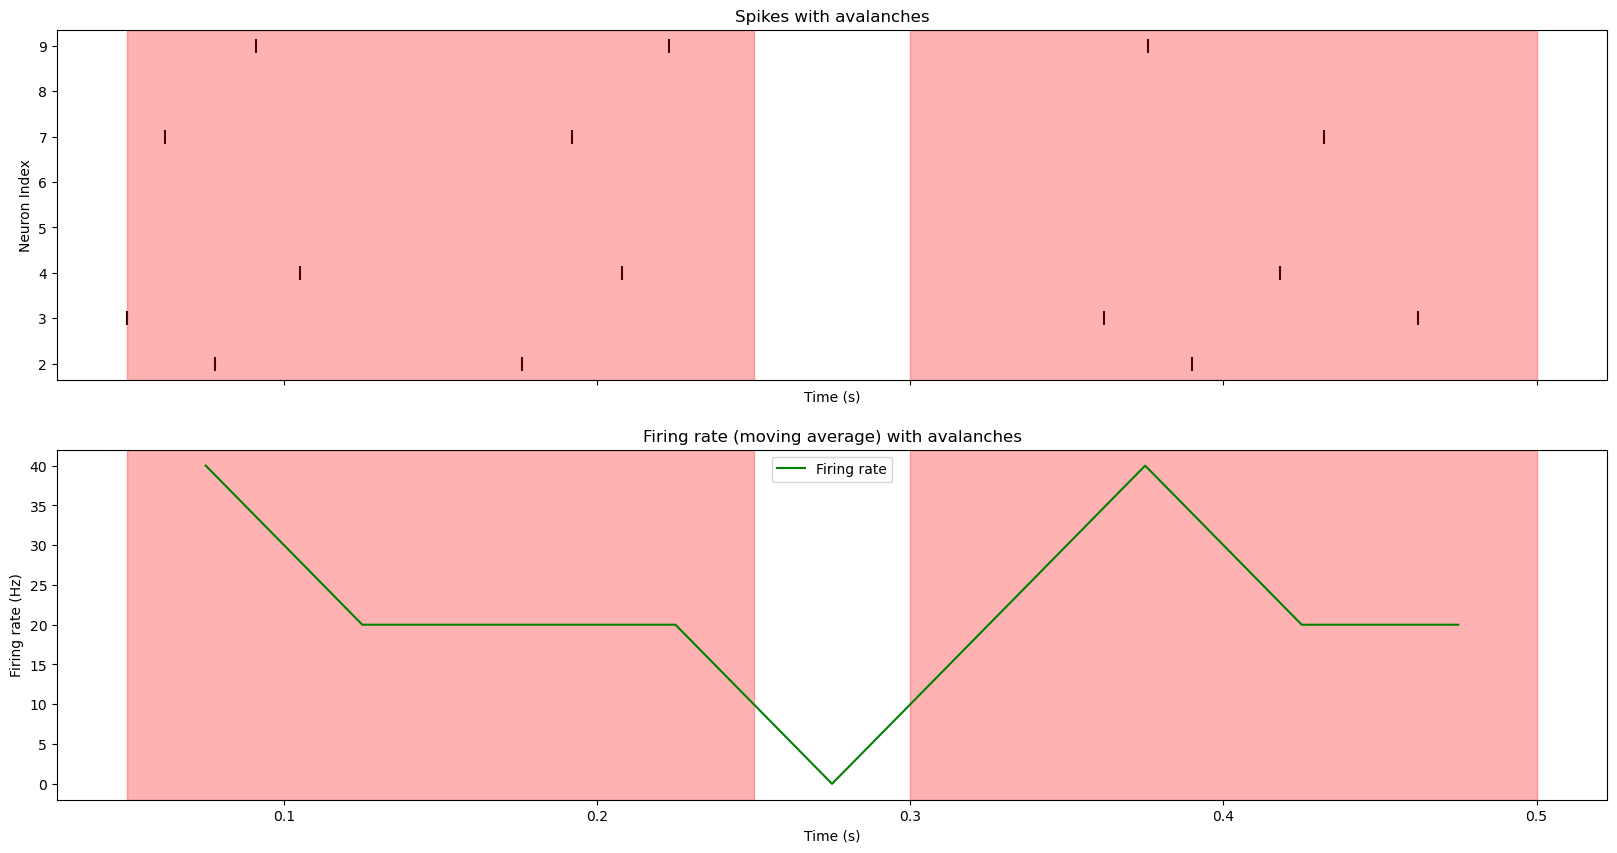

In [45]:
avalanchesplot(session, spikes, neurons=5, tmax=0.5, threshold=10)

In [3]:
def Generalavalanchesplot(session=None, spikes=None, FR=None, bin_size=0.05, neurons=None, tmax=50, threshold=30, smoothed=False, window=5, time_step=None):#neurons = nombre de neurones à prendre en compte, tmax = durée max à prendre en compte, threshold = seuil pour définir les avalanches, smoothed = si on veut afficher la courbe lissée, window = taille de la fenêtre pour le lissage 
    
    if spikes is None and session is None:
        return "Please provide either a session or spike times."
    if session is not None and spikes is None:
        spikes_indiv = fma.data.loadSpikeTimes(session)
    if spikes is not None:
        spikes_indiv = {}
        d = {}
        for value, neuron in spikes:
            neuron = np.uint(neuron)
            if neuron not in d:
                d[neuron] = []
            d[neuron].append(value)
        for neuron, values in d.items():
            spikes_indiv[neuron] = values
    if neurons is not None:
        spikes_indiv = dict(list(spikes_indiv.items())[:neurons])
    spikes_indiv = {key: fma.general.restrict(spikes_indiv[key], [0, tmax]) for key in spikes_indiv} 
    


    if spikes is None:
        spikes = fma.data.loadSpikeTimes(session, output='compact')
    spikes_tot = spikes
    if neurons is not None:
        ind = spikes[:,1] < neurons
        spikes = spikes[ind,:]
    spikes = spikes[(spikes[:,0] >= 0) & (spikes[:,0] <= tmax),:]
    if FR is None:
        FR = fma.analysis.firingRate(spikes_tot, bin_size=bin_size)
    FR_tot = FR
    FR = FR[FR[:,0] <= tmax,:]
    time = FR[:, 0]
    rates = FR[:, 1]
    rates_tot = FR_tot[:, 1] 
    if smoothed:
        smoothed_rates = np.convolve(rates, np.ones(window)/window, mode='same')
    if time_step is None:
        time_step=FR[1,0] - FR[0,0]

    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates_tot,
        threshold=threshold,
        time_step=time_step,
        t0=FR[0,0]
    )

    intervals = intervals[intervals[:,1]<=tmax] 
    

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10), sharex=True)

    for n, (neuron_id, spike_times) in enumerate(spikes_indiv.items()):
    # transforme la liste en array si nécessaire
        spike_times = np.array(spike_times)
    
    # y = n pour ce neurone
        ax1.scatter(spike_times, 
                [neuron_id] * len(spike_times), 
                marker='|', 
                s=100,     # taille du trait
                color='black')
    
    for t1, t2 in intervals:
        ax1.axvspan(t1, t2, color='red', alpha=0.3)


    ax2.plot(time[:len(rates)] , rates, color='green', label='Firing rate')
    if smoothed:
        ax2.plot(time[:len(smoothed_rates)], smoothed_rates, color='blue', label='Smoothed firing rate')
    for t1, t2 in intervals:
        ax2.axvspan(t1, t2, color='red', alpha=0.3)

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Neuron Index")
    ax1.set_title("Spikes with avalanches")

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Firing rate (Hz)")
    ax2.set_title("Firing rate (moving average) with avalanches")
    ax2.legend()

    
    plt.show()


In [4]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])
spikes = R.spikes(regs=["nr"], state='sws')
print(len(spikes))
fr = R.firingRate(regs=["nr"], states='sws', window=0.01, step=1)
print(fr[:5])


553644
[[243.605   0.   ]
 [243.615 200.   ]
 [243.625 200.   ]
 [243.635 100.   ]
 [243.645 200.   ]]


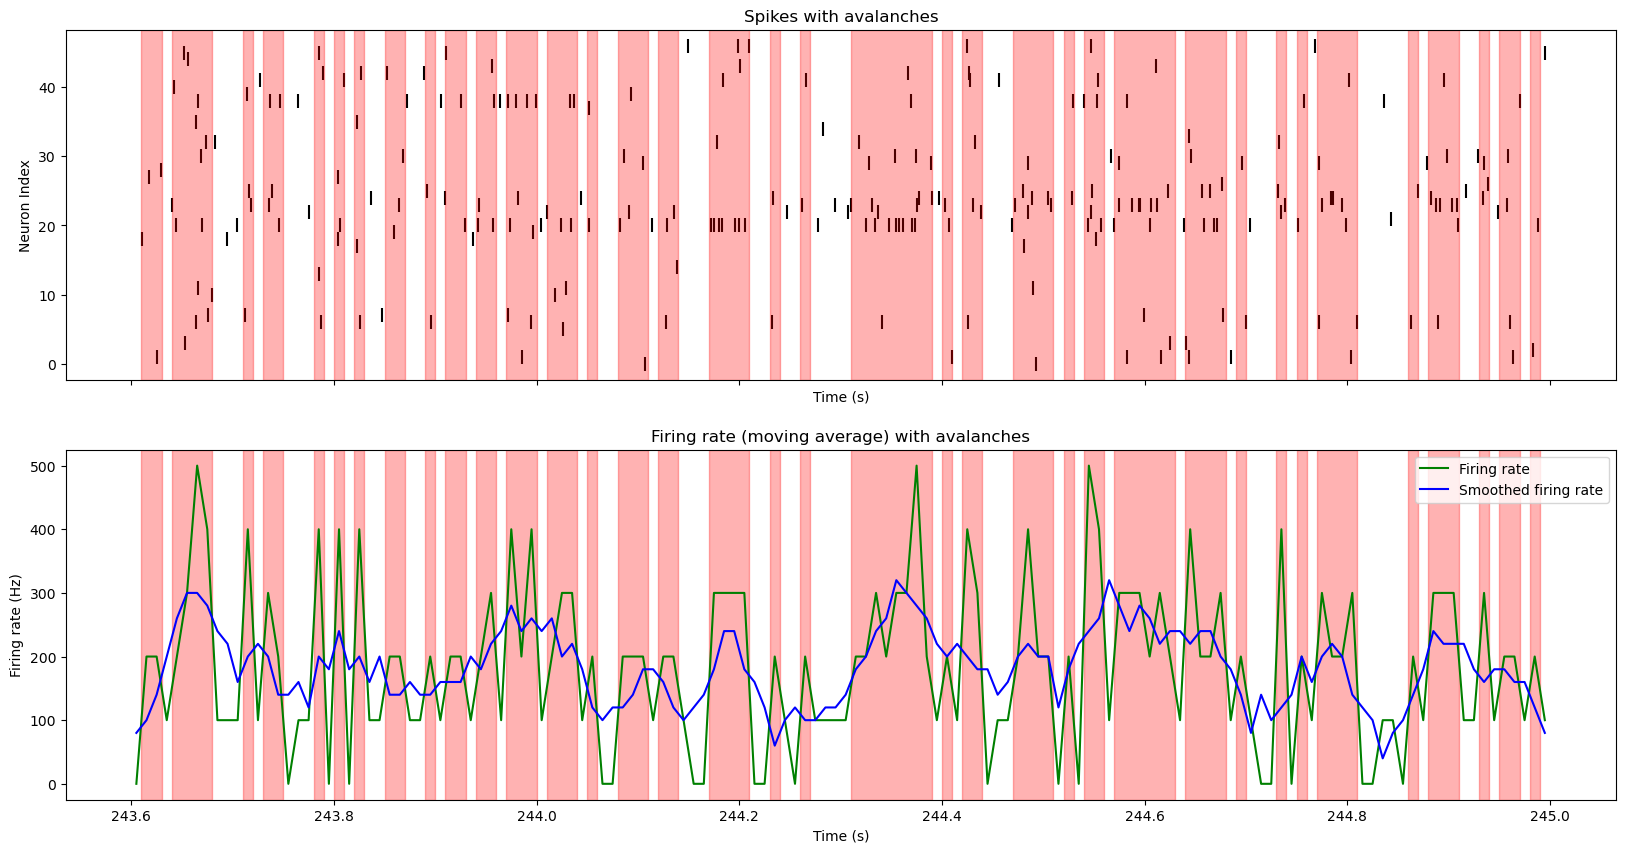

In [5]:
Generalavalanchesplot(spikes=spikes, FR=fr,tmax=245, smoothed=True, bin_size = 0.05, threshold=50, window=5)

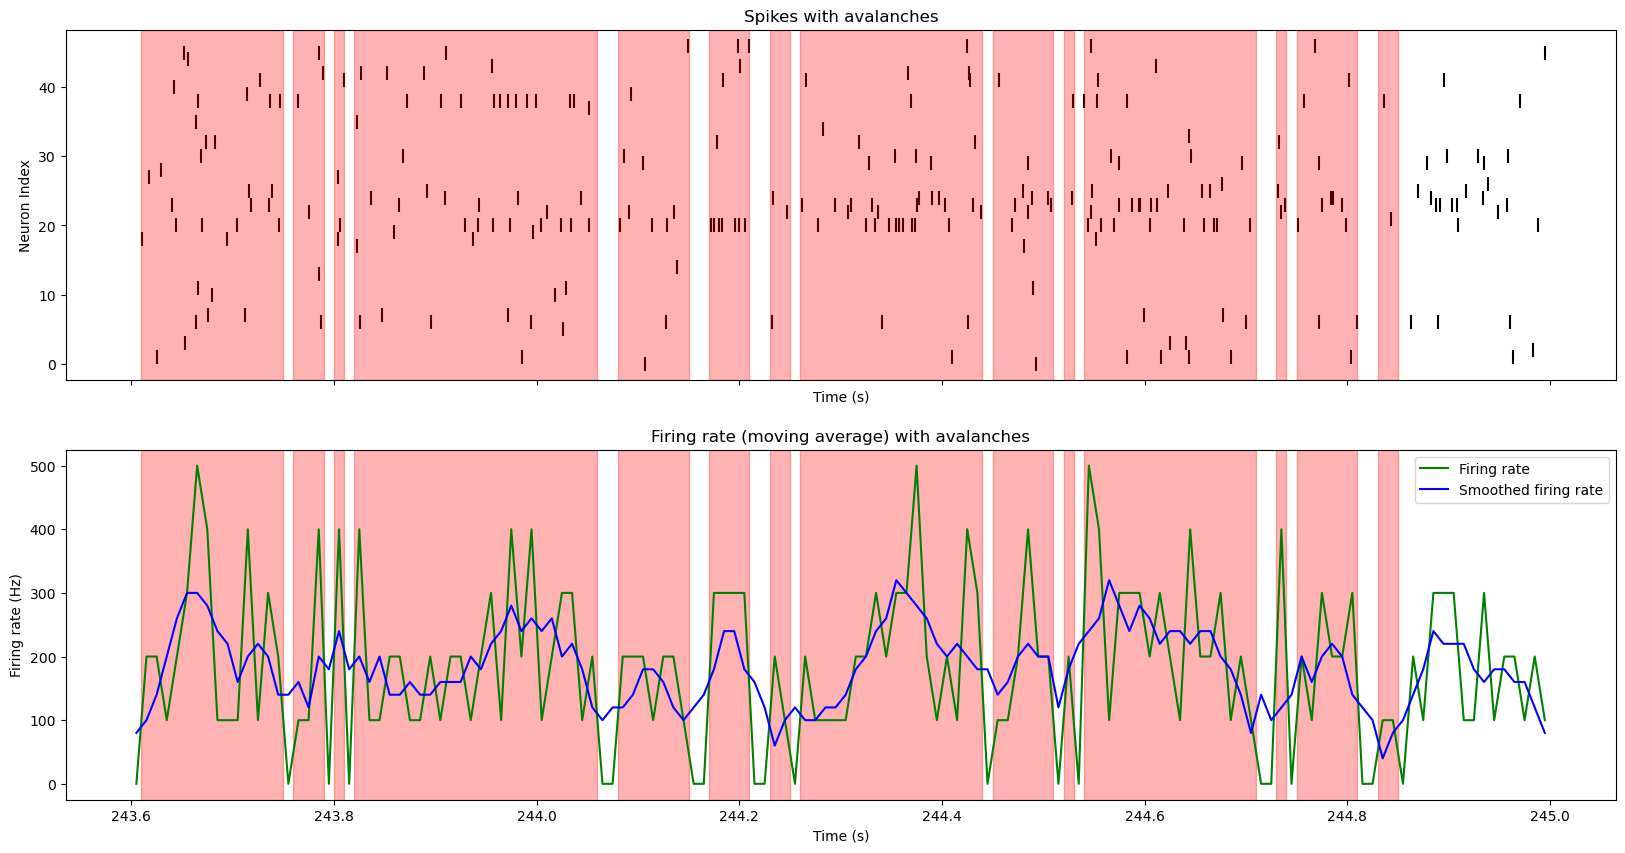

In [50]:
Generalavalanchesplot(spikes=spikes, FR=fr,tmax=245, smoothed=True, bin_size = 0.055945, threshold=0, window=5)

[[243.635 243.74 ]
 [243.775 243.81 ]
 [243.95  244.055]
 [244.3   244.44 ]
 [244.475 244.51 ]
 [244.545 244.685]
 [244.755 244.79 ]
 [244.86  244.965]
 [245.    245.035]
 [245.07  245.105]
 [245.14  245.21 ]
 [245.595 245.63 ]
 [245.7   245.77 ]
 [245.945 245.98 ]
 [246.155 246.26 ]
 [246.295 246.33 ]
 [246.365 246.47 ]
 [246.505 246.54 ]
 [246.575 246.61 ]
 [246.855 246.89 ]
 [246.925 246.96 ]
 [246.995 247.03 ]
 [247.1   247.17 ]
 [247.205 247.31 ]
 [247.345 247.38 ]
 [247.45  247.485]
 [247.52  247.625]
 [247.66  247.73 ]
 [247.835 247.87 ]
 [247.905 247.975]
 [248.045 248.08 ]
 [248.115 248.22 ]
 [248.255 248.29 ]
 [248.36  248.465]
 [248.535 248.64 ]
 [248.675 248.78 ]
 [248.885 248.955]
 [248.99  249.06 ]
 [249.095 249.13 ]
 [249.165 249.375]
 [249.41  249.62 ]
 [249.655 249.795]
 [249.83  249.935]
 [250.04  250.075]
 [250.11  250.145]
 [250.18  250.215]
 [250.355 250.425]
 [250.635 250.775]
 [250.985 251.09 ]
 [251.16  251.265]
 [251.335 251.44 ]
 [251.545 251.72 ]
 [251.79  25

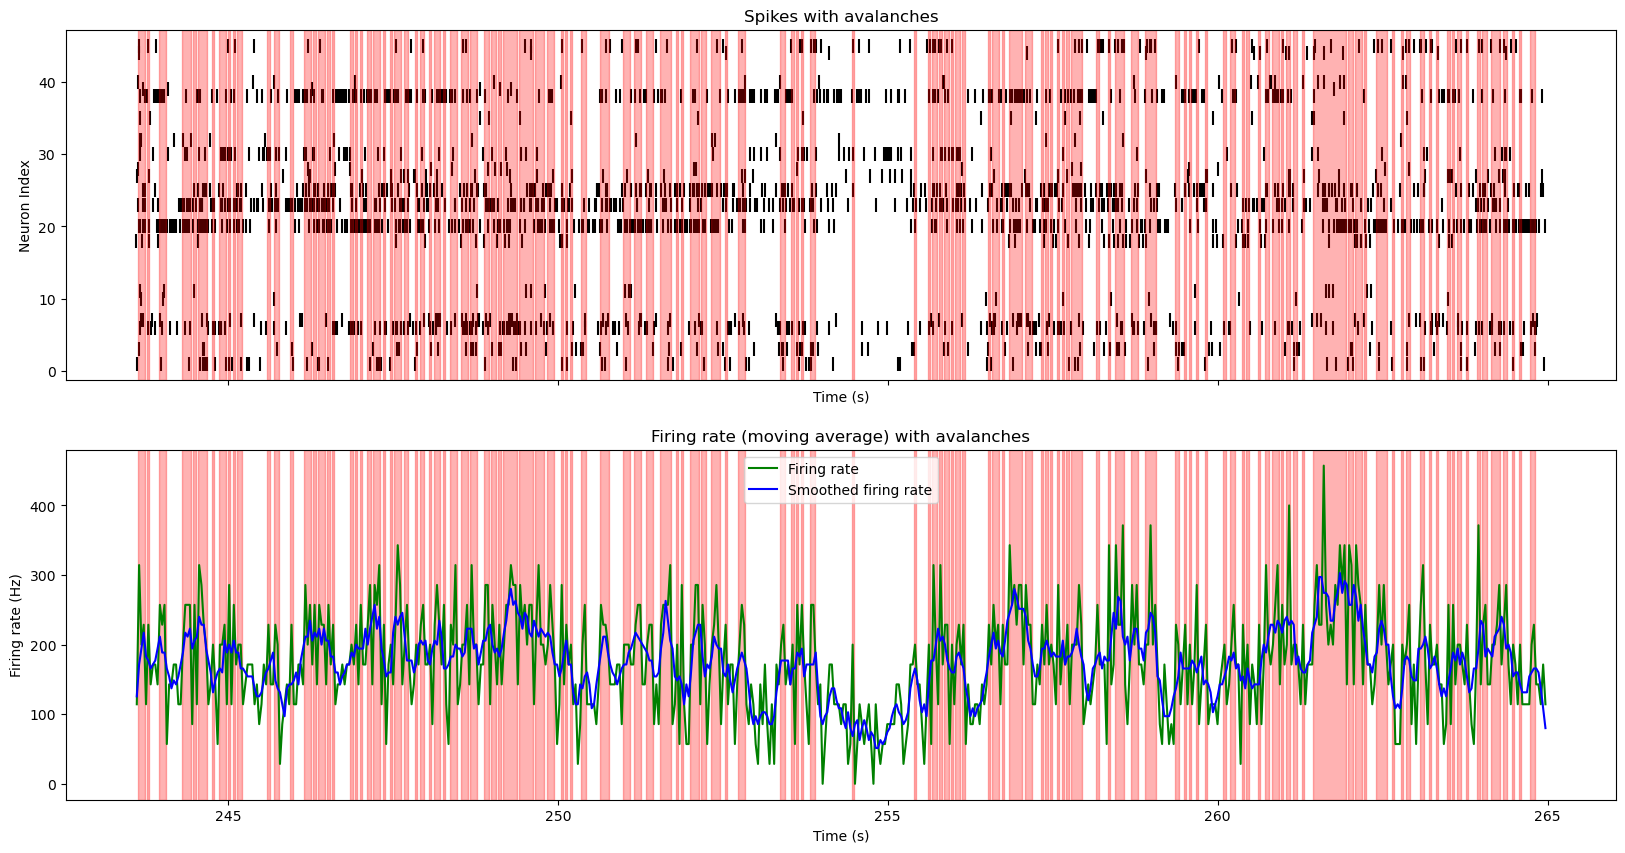

In [10]:
bin_size=0.035
threshold=50
tmax = 265
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

R = rg.data.Regions(session,states=['sws','rem'])
spikes = R.spikes(regs=["nr"], state='sws')
FR = R.firingRate(regs=["nr"], states='sws', window=bin_size, step=1)

avalanchesplot(
        spikes=spikes, FR=FR,
        bin_size=bin_size, tmax=tmax, neurons=20, threshold=threshold,
        smoothed=True, window=5
    )